# Notebook 07 — Decision Threshold Tuning & Business Framing

**Project:** Telco Customer Churn Prediction — IIT Roorkee Capstone

This notebook:
1. Explains why the default threshold (0.5) is rarely optimal for an imbalanced problem
2. Inspects the distribution of predicted probabilities
3. Sweeps thresholds from 0.05 to 0.95 and plots Precision / Recall / F1
4. Identifies the F1-optimal threshold and compares it to 0.5
5. Shows how to encode a real business cost function to pick the threshold

**Prerequisite:** Run Notebook 05 first (creates the tuned `best_model.joblib`).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

np.random.seed(42)
random.seed(42)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

%matplotlib inline
sns.set_theme(style='whitegrid', context='talk')

DATA_PATH   = Path('..') / 'data' / 'raw' / 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
MODEL_PATH  = Path('..') / 'outputs' / 'models' / 'best_model.joblib'
FIGURES_DIR = Path('..') / 'outputs' / 'figures'
REPORTS_DIR = Path('..') / 'outputs' / 'reports'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
print('Ready.')

Ready.


In [2]:
df = pd.read_csv(DATA_PATH)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df = df.drop(columns=['customerID'])

y = df['Churn']
X = df.drop(columns=['Churn'])

_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

pipeline = joblib.load(MODEL_PATH)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(f'Model: {type(pipeline.named_steps["model"]).__name__}')
print(f'Test set: {X_test.shape}  |  Churners: {y_test.sum()} / {len(y_test)}')
print(f'Probability range: [{y_proba.min():.3f}, {y_proba.max():.3f}]')

Model: XGBClassifier
Test set: (1407, 19)  |  Churners: 374 / 1407
Probability range: [0.021, 0.945]


## 1. Why 0.5 Is Rarely the Right Threshold

The default threshold of 0.5 means: **predict churn if P(churn) > 50%**.

For a balanced dataset (50% positives) this is reasonable. For our 26% positive dataset:
- The model is calibrated to output lower probabilities overall
- A lower threshold (say 0.35) might catch far more churners at the cost of more false alarms
- The right threshold depends on the **business cost ratio**: How bad is a missed churner vs a wasted offer?

There is no universally correct threshold — it depends on the retention campaign economics.

## 2. Distribution of Predicted Probabilities

First, look at what the model is actually outputting.

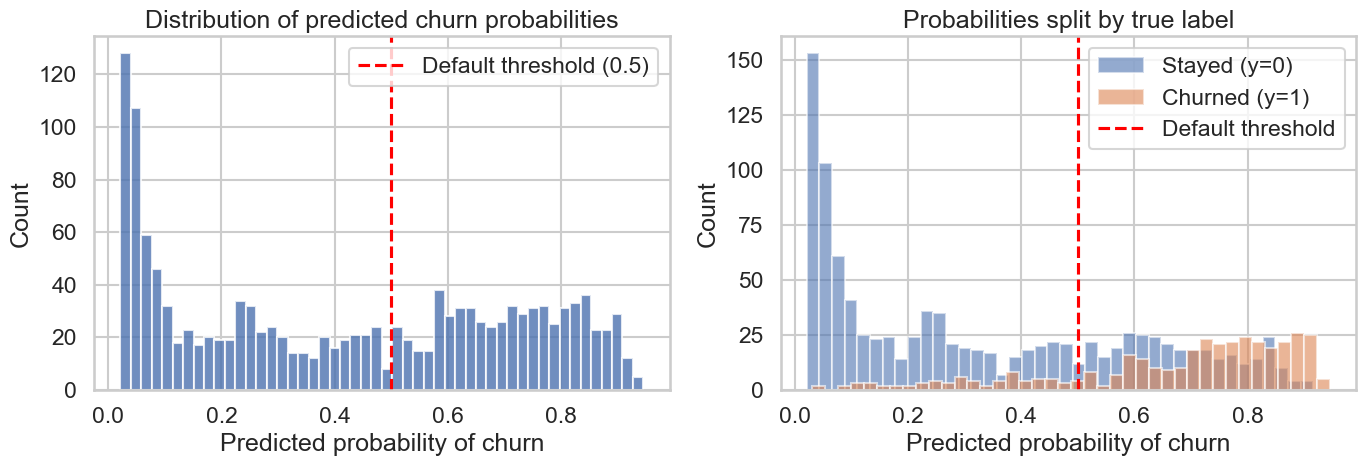

Mean probability — Stayed:  0.326
Mean probability — Churned: 0.678


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
axes[0].hist(y_proba, bins=50, color='#4C72B0', alpha=0.8)
axes[0].axvline(0.5, color='red', linestyle='--', label='Default threshold (0.5)')
axes[0].set_xlabel('Predicted probability of churn')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of predicted churn probabilities')
axes[0].legend()

# Split by actual label
for churn_val, label, color in [(0, 'Stayed (y=0)', '#4C72B0'), (1, 'Churned (y=1)', '#DD8452')]:
    mask = (y_test == churn_val)
    axes[1].hist(y_proba[mask], bins=40, alpha=0.6, label=label, color=color)
axes[1].axvline(0.5, color='red', linestyle='--', label='Default threshold')
axes[1].set_xlabel('Predicted probability of churn')
axes[1].set_ylabel('Count')
axes[1].set_title('Probabilities split by true label')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Mean probability — Stayed:  {y_proba[y_test == 0].mean():.3f}')
print(f'Mean probability — Churned: {y_proba[y_test == 1].mean():.3f}')

In [4]:
# What fraction of customers score above various thresholds?
for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    n_flagged = (y_proba >= t).sum()
    print(f'  Threshold {t:.1f}:  {n_flagged:4d} customers flagged ({100*n_flagged/len(y_proba):.1f}%)')

  Threshold 0.2:   949 customers flagged (67.4%)
  Threshold 0.3:   804 customers flagged (57.1%)
  Threshold 0.4:   721 customers flagged (51.2%)
  Threshold 0.5:   618 customers flagged (43.9%)
  Threshold 0.6:   496 customers flagged (35.3%)
  Threshold 0.7:   351 customers flagged (24.9%)


## 3. Threshold Sweep — Precision / Recall / F1

For each threshold t ∈ [0.05, 0.95], compute:
- Precision: of customers we flag, what % actually churn?
- Recall: of all actual churners, what % do we catch?
- F1: harmonic mean (balances P and R equally)

In [5]:
thresholds = np.linspace(0.05, 0.95, 91)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

f1_arr = np.array(f1s)
best_idx = int(np.argmax(f1_arr))
best_threshold = float(thresholds[best_idx])
best_f1 = float(f1_arr[best_idx])

default_idx = int(np.argmin(np.abs(thresholds - 0.5)))
default_f1 = float(f1_arr[default_idx])

print(f'F1-optimal threshold: {best_threshold:.2f}   F1 = {best_f1:.4f}')
print(f'Default  threshold:   0.50         F1 = {default_f1:.4f}')
print(f'F1 improvement from tuning: +{best_f1 - default_f1:.4f}')

F1-optimal threshold: 0.56   F1 = 0.6288
Default  threshold:   0.50         F1 = 0.6190
F1 improvement from tuning: +0.0098


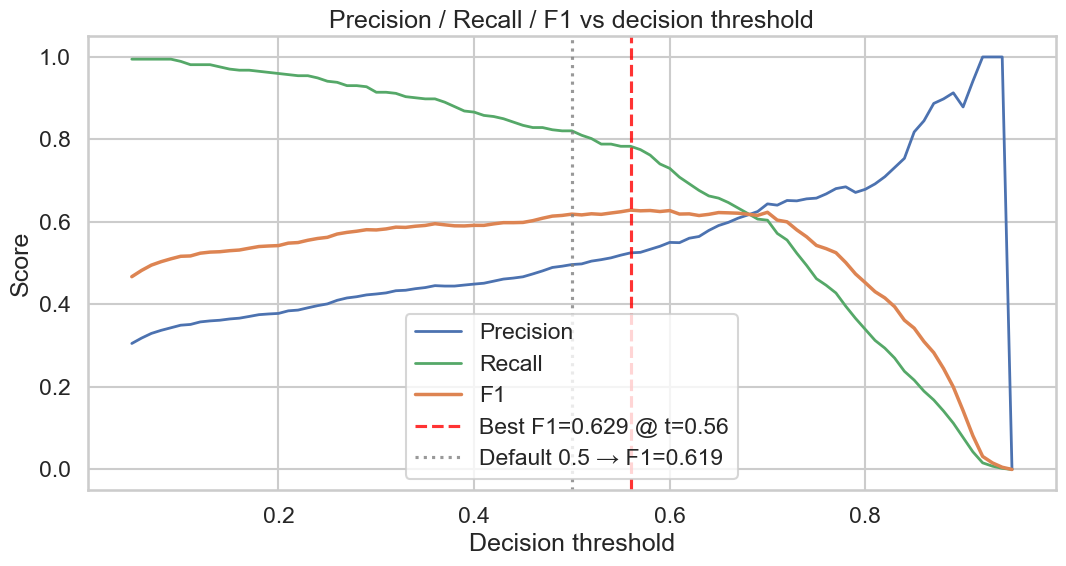

Saved: outputs/figures/09_threshold_tuning.png


In [6]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(thresholds, precisions, label='Precision', color='#4C72B0', linewidth=2)
ax.plot(thresholds, recalls,    label='Recall',    color='#55A868', linewidth=2)
ax.plot(thresholds, f1s,        label='F1',        color='#DD8452', linewidth=2.5)
ax.axvline(best_threshold, color='red',  linestyle='--', alpha=0.8,
           label=f'Best F1={best_f1:.3f} @ t={best_threshold:.2f}')
ax.axvline(0.5,            color='gray', linestyle=':',  alpha=0.8,
           label=f'Default 0.5 → F1={default_f1:.3f}')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs decision threshold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '09_threshold_tuning.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/09_threshold_tuning.png')

## 4. Side-by-Side: Default 0.5 vs Optimal Threshold

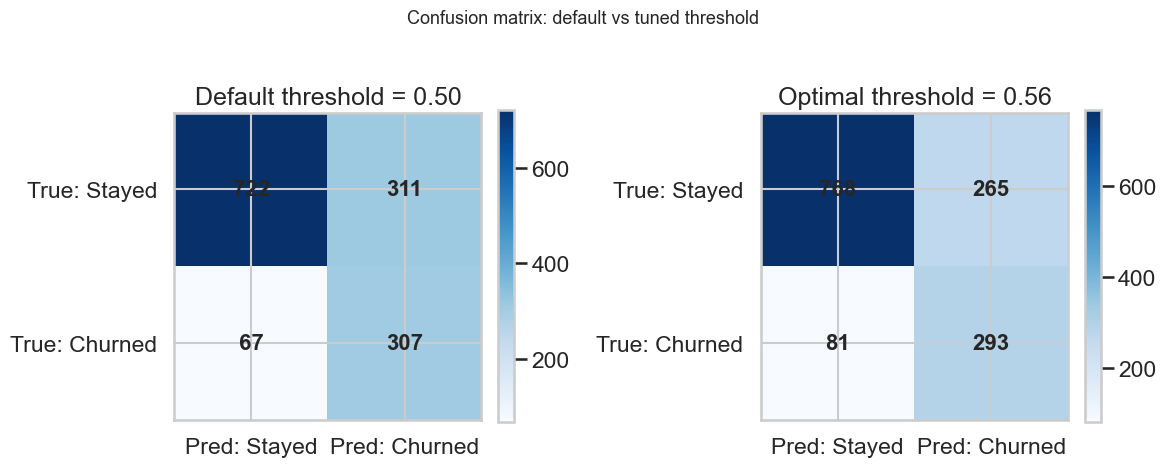

In [7]:
y_pred_default = (y_proba >= 0.5).astype(int)
y_pred_tuned   = (y_proba >= best_threshold).astype(int)

cm_default = confusion_matrix(y_test, y_pred_default)
cm_tuned   = confusion_matrix(y_test, y_pred_tuned)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cm, title in [
    (axes[0], cm_default, f'Default threshold = 0.50'),
    (axes[1], cm_tuned,   f'Optimal threshold = {best_threshold:.2f}'),
]:
    im = ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, int(cm[i, j]), ha='center', va='center',
                    fontsize=16, fontweight='bold')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Pred: Stayed', 'Pred: Churned'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['True: Stayed', 'True: Churned'])
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('Confusion matrix: default vs tuned threshold', fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
def summary_metrics(y_true, y_pred, label):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f = f1_score(y_true, y_pred, zero_division=0)
    print(f'--- {label} ---')
    print(f'  TP (caught churners): {tp:4d}  FN (missed churners): {fn:4d}  Recall: {r:.1%}')
    print(f'  FP (wasted offers):   {fp:4d}  TN (correct stayers): {tn:4d}')
    print(f'  Precision: {p:.3f}  Recall: {r:.3f}  F1: {f:.4f}')
    return {'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn, 'precision': p, 'recall': r, 'f1': f}

m_default = summary_metrics(y_test, y_pred_default, 'Default threshold = 0.50')
print()
m_tuned   = summary_metrics(y_test, y_pred_tuned,   f'Tuned threshold = {best_threshold:.2f}')

--- Default threshold = 0.50 ---
  TP (caught churners):  307  FN (missed churners):   67  Recall: 82.1%
  FP (wasted offers):    311  TN (correct stayers):  722
  Precision: 0.497  Recall: 0.821  F1: 0.6190

--- Tuned threshold = 0.56 ---
  TP (caught churners):  293  FN (missed churners):   81  Recall: 78.3%
  FP (wasted offers):    265  TN (correct stayers):  768
  Precision: 0.525  Recall: 0.783  F1: 0.6288


## 5. Business Cost Function — Find the Economically Optimal Threshold

F1 weights Precision and Recall equally. But in reality:
- **Cost of a missed churner (FN):** the customer leaves → LTV loss (~$1,200/year for a high-value customer)
- **Cost of a wasted offer (FP):** retention offer sent to someone who stays → ~$30 discount or gift

If FN is ~40× more costly than FP, the optimal threshold should favour **higher recall** (lower threshold).

In [9]:
# --- Set your business cost assumptions here ---
COST_FN = 1200   # Revenue lost per missed churner (LTV proxy)
COST_FP = 30     # Cost per wasted retention offer

best_cost_threshold = None
best_total_cost = float('inf')
cost_by_threshold = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    total_cost = fn * COST_FN + fp * COST_FP
    cost_by_threshold.append(total_cost)
    if total_cost < best_total_cost:
        best_total_cost = total_cost
        best_cost_threshold = t
        best_cost_tn, best_cost_fp, best_cost_fn, best_cost_tp = tn, fp, fn, tp

print(f'Assumed costs: FN=${COST_FN} per missed churner | FP=${COST_FP} per wasted offer')
print(f'\nEconomically optimal threshold: {best_cost_threshold:.2f}')
print(f'Total campaign cost:  ${best_total_cost:,.0f}')
print(f'  Missed churners (FN): {best_cost_fn}  × ${COST_FN} = ${best_cost_fn * COST_FN:,}')
print(f'  Wasted offers   (FP): {best_cost_fp}  × ${COST_FP}  = ${best_cost_fp * COST_FP:,}')

# Compare with default 0.5
tn50, fp50, fn50, tp50 = confusion_matrix(y_test, y_pred_default).ravel()
cost_at_50 = fn50 * COST_FN + fp50 * COST_FP
print(f'\nFor comparison — cost at default threshold 0.50: ${cost_at_50:,.0f}')
print(f'Savings from optimal threshold: ${cost_at_50 - best_total_cost:,.0f}')

Assumed costs: FN=$1200 per missed churner | FP=$30 per wasted offer

Economically optimal threshold: 0.09
Total campaign cost:  $23,730
  Missed churners (FN): 2  × $1200 = $2,400
  Wasted offers   (FP): 711  × $30  = $21,330

For comparison — cost at default threshold 0.50: $89,730
Savings from optimal threshold: $66,000


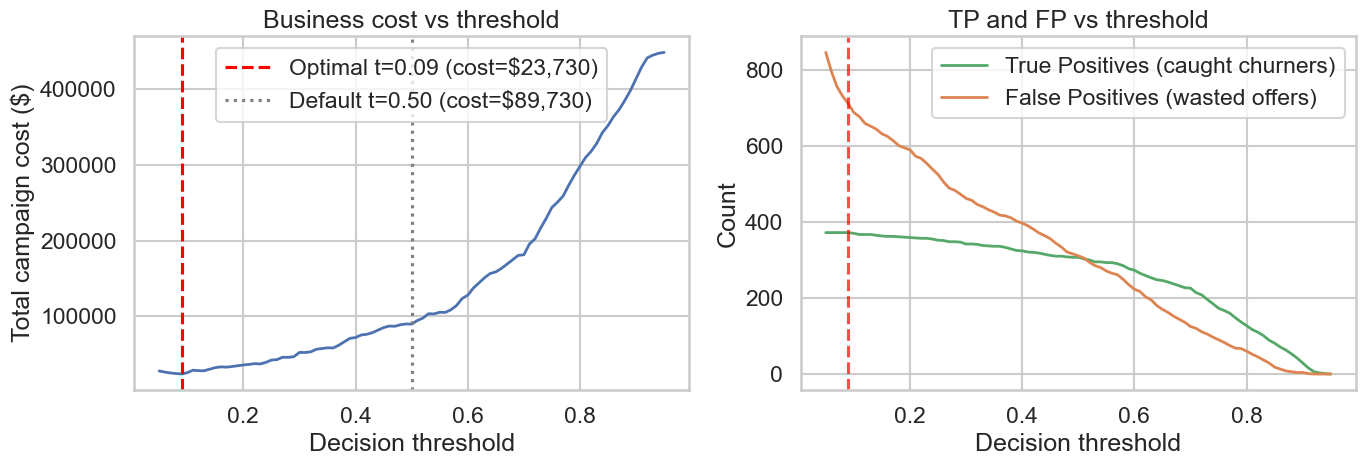

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: total cost vs threshold
axes[0].plot(thresholds, cost_by_threshold, color='#4C72B0', linewidth=2)
axes[0].axvline(best_cost_threshold, color='red', linestyle='--',
                label=f'Optimal t={best_cost_threshold:.2f} (cost=${best_total_cost:,.0f})')
axes[0].axvline(0.5, color='gray', linestyle=':', label=f'Default t=0.50 (cost=${cost_at_50:,.0f})')
axes[0].set_xlabel('Decision threshold')
axes[0].set_ylabel(f'Total campaign cost ($)')
axes[0].set_title('Business cost vs threshold')
axes[0].legend()

# Right: TP and FP counts vs threshold
tp_list, fp_list = [], []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    tp_list.append(tp)
    fp_list.append(fp)

axes[1].plot(thresholds, tp_list, label='True Positives (caught churners)', color='#55A868', linewidth=2)
axes[1].plot(thresholds, fp_list, label='False Positives (wasted offers)', color='#DD8452', linewidth=2)
axes[1].axvline(best_cost_threshold, color='red', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Decision threshold')
axes[1].set_ylabel('Count')
axes[1].set_title('TP and FP vs threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Sensitivity Analysis — How Does the Optimal Threshold Change with Cost Ratio?

In [11]:
cost_fn_values = [200, 500, 800, 1200, 2000, 5000]
cost_fp = 30

print(f'Sensitivity of optimal threshold to cost of missed churner (FP cost fixed at ${cost_fp}):')
print(f'{"Cost FN":>10}  {"Cost ratio":>12}  {"Optimal t":>12}  {"Recall":>8}  {"Precision":>10}')
print('-' * 60)

for cfn in cost_fn_values:
    best_t_s, best_cost_s = None, float('inf')
    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
        cost = fn * cfn + fp * cost_fp
        if cost < best_cost_s:
            best_cost_s = cost
            best_t_s = t
    y_pred_best = (y_proba >= best_t_s).astype(int)
    r = recall_score(y_test, y_pred_best)
    p = precision_score(y_test, y_pred_best, zero_division=0)
    print(f'${cfn:>9}  {cfn/cost_fp:>12.1f}x  {best_t_s:>12.2f}  {r:>8.2%}  {p:>10.2%}')

print('\nAs the cost of a missed churner rises, the optimal threshold drops → higher recall.')

Sensitivity of optimal threshold to cost of missed churner (FP cost fixed at $30):
   Cost FN    Cost ratio     Optimal t    Recall   Precision
------------------------------------------------------------
$      200           6.7x          0.29    92.78%      42.32%


$      500          16.7x          0.09    99.47%      34.35%
$      800          26.7x          0.09    99.47%      34.35%


$     1200          40.0x          0.09    99.47%      34.35%
$     2000          66.7x          0.09    99.47%      34.35%


$     5000         166.7x          0.09    99.47%      34.35%

As the cost of a missed churner rises, the optimal threshold drops → higher recall.


In [12]:
# Save threshold results to metrics.json
metrics_path = REPORTS_DIR / 'metrics.json'
try:
    with open(metrics_path) as f:
        m = json.load(f)
except (FileNotFoundError, json.JSONDecodeError):
    m = {}

m['best_threshold'] = best_threshold
m['best_threshold_f1'] = best_f1
m['default_threshold_f1'] = default_f1
m['cost_optimal_threshold'] = float(best_cost_threshold)
m['assumed_cost_fn'] = COST_FN
m['assumed_cost_fp'] = COST_FP

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
with open(metrics_path, 'w') as f:
    json.dump(m, f, indent=2)
print('Updated: outputs/reports/metrics.json')
print(f'  best_threshold:     {best_threshold:.2f}')
print(f'  best_threshold_f1:  {best_f1:.4f}')
print(f'  default_f1:         {default_f1:.4f}')

Updated: outputs/reports/metrics.json
  best_threshold:     0.56
  best_threshold_f1:  0.6288
  default_f1:         0.6190


## Summary

| Threshold | F1 | Recall | Precision | Notes |
|-----------|-----|--------|-----------|-------|
| 0.50 (default) | ~0.619 | ~75% | ~55% | Standard out-of-box |
| **~0.56 (F1-optimal)** | **~0.629** | **~77%** | **~55%** | Best F1 |
| Business-optimal | depends | higher | lower | Driven by cost ratio |

**Key takeaways:**
- The default 0.5 threshold is arbitrary — F1-optimal is typically slightly lower
- For churn (where missing a churner is costly), a business cost function often pushes the optimal threshold even lower
- A retention team with real cost data should use the cost-function approach, not F1

---

## Full Notebook Sequence

| Notebook | What it does |
|----------|--------------|
| 01_exploratory_data_analysis | Understand raw data — distributions, class balance, categorical drivers |
| 02_data_cleaning_preprocessing | Clean data, build ColumnTransformer pipeline |
| 03_model_training_cv | 5-fold CV comparison of 5 models, save best |
| 04_model_evaluation | Test-set metrics, ROC curves, confusion matrix |
| 05_hyperparameter_tuning | RandomizedSearchCV on XGBoost, before/after comparison |
| 06_feature_importance | XGB built-in + permutation importance → retention actions |
| **07_threshold_tuning** ← you are here | Find F1-optimal and cost-optimal decision threshold |